---
## 0. Importações e Configurações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import warnings
from pathlib import Path

from statsmodels.tsa.seasonal import STL

warnings.filterwarnings("ignore")

# Paths
BASE_DIR = Path("..").resolve()
DATA_RAW = BASE_DIR / "data" / "raw"
DATA_PROC = BASE_DIR / "data" / "processed"
PLOTS_DIR = BASE_DIR / "results" / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
DATA_PROC.mkdir(parents=True, exist_ok=True)

# Estilo visual
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {
    "cativo":   "#D62728",   # vermelho — mercado cativo (CELESC)
    "livre":    "#1F77B4",   # azul — mercado livre (CCEE)
    "saving":   "#2CA02C",   # verde — economia
    "projecao": "#FF7F0E",   # laranja — projeção
    "evento":   "#9467BD",   # roxo — eventos regulatórios
}

print("✅ Configurações carregadas.")

✅ Configurações carregadas.


---
## 1. Tarifas ANEEL — CELESC Subgrupo B3

TE e TUSD homologadas pela ANEEL para a CELESC (Subgrupo B3, modalidade Convencional), em série mensal contínua (`tarifa_b3_celesc_mensal.csv`, gerado pelo notebook 00).
Fonte: https://dadosabertos.aneel.gov.br/dataset/tarifas-distribuidoras-energia-eletrica

In [2]:
# Usa a série já tratada pelo Notebook 0 (filtro DscDetalhe=='Não se aplica',
# DscBaseTarifaria=='Tarifa de Aplicação'; vigências expandidas em série mensal contínua).
df_tarifa_mensal = pd.read_csv(DATA_PROC / "tarifa_b3_celesc_mensal.csv", parse_dates=["data"])
df_tarifa_mensal = df_tarifa_mensal.set_index("data").asfreq("MS")
df_tarifa_mensal["ano"] = df_tarifa_mensal.index.year

tarifa_anual = (
    df_tarifa_mensal.groupby("ano")
    .agg(tarifa_celesc_mwh=("tarifa_cativo_rs_mwh", "mean"),
         tusd_mwh=("tusd_b3_rs_mwh", "mean"))
    .reset_index()
)
tarifa_anual["tarifa_celesc_kwh"] = tarifa_anual["tarifa_celesc_mwh"] / 1000
tarifa_anual["tusd_kwh"] = tarifa_anual["tusd_mwh"] / 1000

print(f'Tarifa B3 CELESC (mensal): {df_tarifa_mensal.index.min():%Y-%m} a {df_tarifa_mensal.index.max():%Y-%m}')
tarifa_anual.tail()

Tarifa B3 CELESC (mensal): 2010-08 a 2027-08


,ano,tarifa_celesc_mwh,tusd_mwh,tarifa_celesc_kwh,tusd_kwh
13,2023,579.666667,307.123333,0.579667,0.307123
14,2024,601.276667,305.483333,0.601277,0.305483
15,2025,643.833333,335.030000,0.643833,0.335030
16,2026,717.036667,387.180000,0.717037,0.387180
17,2027,759.750000,414.040000,0.759750,0.414040


---
## 2. PLD Submercado Sul (CCEE)

PLD médio mensal do submercado Sul (`pld_sul_mensal.csv`, gerado pelo notebook 00).

Na comparação histórica da Seção 4, o custo no mercado livre é estimado como:

$$\text{Custo ML} = \text{PLD}_\text{Sul} + \text{TUSD}_\text{B3} + \text{Encargos e margem}$$

com encargos e margem fixados em R$ 0,077/kWh (valor de referência). A composição detalhada dos encargos está na Seção 6.1.

In [3]:
# PLD real (CCEE) + TUSD real (ANEEL) + encargos e margem (valor fixo de referência).
df_pld_mensal_ccee = pd.read_csv(DATA_PROC / "pld_sul_mensal.csv", parse_dates=["data"])
df_pld_mensal_ccee = df_pld_mensal_ccee.set_index("data").asfreq("MS")
df_pld_mensal_ccee["ano"] = df_pld_mensal_ccee.index.year

df_pld = (
    df_pld_mensal_ccee.groupby("ano")["pld_sul_rs_mwh"].mean().reset_index()
    .rename(columns={"pld_sul_rs_mwh": "pld_sul_mwh"})
)
df_pld["pld_sul_kwh"] = df_pld["pld_sul_mwh"] / 1000
df_pld = df_pld.merge(tarifa_anual[["ano", "tusd_kwh"]], on="ano", how="left")

# Encargos setoriais + margem de comercializadora, residual à TUSD real (que já vem de tarifa_anual)
# -- valor mantido constante por falta de série histórica própria para esse componente.
ENCARGOS_MARGEM_KWH = 0.077

df_pld["encargos_kwh"] = df_pld["tusd_kwh"] + ENCARGOS_MARGEM_KWH
df_pld["custo_ml_kwh"] = df_pld["pld_sul_kwh"] + df_pld["encargos_kwh"]
df_pld["custo_ml_kwh_otimista"] = df_pld["pld_sul_kwh"] * 0.85 + df_pld["encargos_kwh"]
df_pld["custo_ml_kwh_pessimista"] = df_pld["pld_sul_kwh"] * 1.20 + df_pld["encargos_kwh"]

print("Série PLD real (CCEE) + TUSD real (ANEEL) + encargos/margem residual (R$/kWh):")
print(df_pld[["ano", "pld_sul_mwh", "pld_sul_kwh", "encargos_kwh", "custo_ml_kwh"]].to_string(index=False))

Série PLD real (CCEE) + TUSD real (ANEEL) + encargos/margem residual (R$/kWh):
 ano  pld_sul_mwh  pld_sul_kwh  encargos_kwh  custo_ml_kwh
2001    51.267571     0.051268           NaN           NaN
2002    13.455833     0.013456           NaN           NaN
2003    13.910292     0.013910           NaN           NaN
2004    18.983667     0.018984           NaN           NaN
2005    33.871542     0.033872           NaN           NaN
2006    69.514375     0.069514           NaN           NaN
2007    91.898750     0.091899           NaN           NaN
2008   136.835250     0.136835           NaN           NaN
2009    40.044750     0.040045           NaN           NaN
2010    70.334750     0.070335      0.247380      0.317715
2011    28.078208     0.028078      0.248553      0.276632
2012   170.594792     0.170595      0.242940      0.413535
2013   253.435167     0.253435      0.191144      0.444579
2014   653.600708     0.653601      0.199447      0.853047
2015   280.535125     0.280535      

---
## 3. Contexto Histórico Regulatório (2010–2025)

Este período é essencial para a interpretação correta das séries temporais de custo.

In [4]:
eventos_regulatorios = [
    {
        "ano": 2010,
        "evento": "Acordo setorial e expansão das renováveis",
        "impacto": "Neutro/positivo",
        "descricao": "Leilões de energia eólica e solar impulsionam diversificação da matriz. "
                     "PLD baixo por boas condições hidrológicas.",
    },
    {
        "ano": 2012,
        "evento": 'MP 579/2012 — "Tarifaço" invertido',
        "impacto": "Distorção estrutural",
        "descricao": "Medida Provisória renova concessões de geração e transmissão com redução "
                     "forçada de ~20% nas tarifas. CELESC recebe cota de energia hidrelétrica "
                     "insuficiente para cobrir demanda, acumulando dívida setorial.",
    },
    {
        "ano": 2013,
        "evento": "Lei 12.783/2013 — conversão da MP 579",
        "impacto": "Passivo regulatório crescente",
        "descricao": "Seca severa força acionamento intensivo de termelétricas (custo médio "
                     ">5x o custo hidrelétrico). Distribuidoras acumulam déficit. "
                     "PLD Sul chega a R$ 421/MWh (média anual de R$ 253/MWh).",
    },
    {
        "ano": 2014,
        "evento": "Crise hídrica crítica — reservatórios no mínimo histórico",
        "impacto": "Máxima exposição de custo no ML",
        "descricao": "PLD atinge o teto regulatório (R$ 822/MWh), com média anual de R$ 654/MWh; "
                     "exposto ao PLD, o custo no Mercado Livre seria cerca de 2,5 vezes o do cativo. "
                     "No mercado cativo, o passivo é represado.",
    },
    {
        "ano": 2015,
        "evento": "Bandeiras Tarifárias (jan/2015) + RTE CELESC (+24,8%)",
        "impacto": "Realinhamento tarifário no cativo",
        "descricao": "Sistema de bandeiras implementado pela ANEEL para repassar em tempo real "
                     "os custos de geração termelétrica. A CELESC passa por Revisão Tarifária "
                     "Extraordinária (RTE) para recompor desequilíbrio financeiro acumulado "
                     "desde 2012. Tarifa B3 sobe ~24,8% em agosto/2015.",
    },
    {
        "ano": 2021,
        "evento": "Segunda Crise Hídrica — PLD no teto histórico",
        "impacto": "Máxima desvantagem do Mercado Livre",
        "descricao": "PLD Sul atinge o teto de R$ 584/MWh em julho (média anual de R$ 279/MWh). "
                     "Exposto ao PLD, o consumidor livre teria pago cerca de 11% a mais que no cativo (com encargos). "
                     "Demonstra o risco hidrológico intrínseco ao modelo de preço spot.",
    },
    {
        "ano": 2025,
        "evento": "Lei 15.269/2025 — Abertura do ML para Grupo B",
        "impacto": "Marco regulatório histórico",
        "descricao": "Define cronograma de migração: B3 comercial/industrial em nov/2027, "
                     "B1 residencial e B2 rural em nov/2028.",
    },
]

df_eventos = pd.DataFrame(eventos_regulatorios)
print("Timeline regulatória construída:")
df_eventos[["ano", "evento", "impacto"]].to_string(index=False)

Timeline regulatória construída:


' ano                                                    evento                             impacto\n2010                 Acordo setorial e expansão das renováveis                     Neutro/positivo\n2012                        MP 579/2012 — "Tarifaço" invertido                Distorção estrutural\n2013                     Lei 12.783/2013 — conversão da MP 579       Passivo regulatório crescente\n2014 Crise hídrica crítica — reservatórios no mínimo histórico     Máxima exposição de custo no ML\n2015     Bandeiras Tarifárias (jan/2015) + RTE CELESC (+24,8%)   Realinhamento tarifário no cativo\n2021             Segunda Crise Hídrica — PLD no teto histórico Máxima desvantagem do Mercado Livre\n2025             Lei 15.269/2025 — Abertura do ML para Grupo B         Marco regulatório histórico'

In [5]:
print("\n" + "=" * 80)
print("📅 LINHA DO TEMPO REGULATÓRIA — Setor Elétrico SC (2010–2025)")
print("=" * 80)
for _, row in df_eventos.iterrows():
    print(f"\n🔹 [{row['ano']}] {row['evento']}")
    print(f"   Impacto: {row['impacto']}")
    print(f"   {row['descricao']}")


📅 LINHA DO TEMPO REGULATÓRIA — Setor Elétrico SC (2010–2025)

🔹 [2010] Acordo setorial e expansão das renováveis
   Impacto: Neutro/positivo
   Leilões de energia eólica e solar impulsionam diversificação da matriz. PLD baixo por boas condições hidrológicas.

🔹 [2012] MP 579/2012 — "Tarifaço" invertido
   Impacto: Distorção estrutural
   Medida Provisória renova concessões de geração e transmissão com redução forçada de ~20% nas tarifas. CELESC recebe cota de energia hidrelétrica insuficiente para cobrir demanda, acumulando dívida setorial.

🔹 [2013] Lei 12.783/2013 — conversão da MP 579
   Impacto: Passivo regulatório crescente
   Seca severa força acionamento intensivo de termelétricas (custo médio >5x o custo hidrelétrico). Distribuidoras acumulam déficit. PLD Sul chega a R$ 421/MWh (média anual de R$ 253/MWh).

🔹 [2014] Crise hídrica crítica — reservatórios no mínimo histórico
   Impacto: Máxima exposição de custo no ML
   PLD atinge o teto regulatório (R$ 822/MWh), com média anua

---
## 4. Gráficos Comparativos de Séries Temporais

### 4.1 Evolução do Custo Unitário (R$/kWh): Cativo vs. Livre (2010–2026)

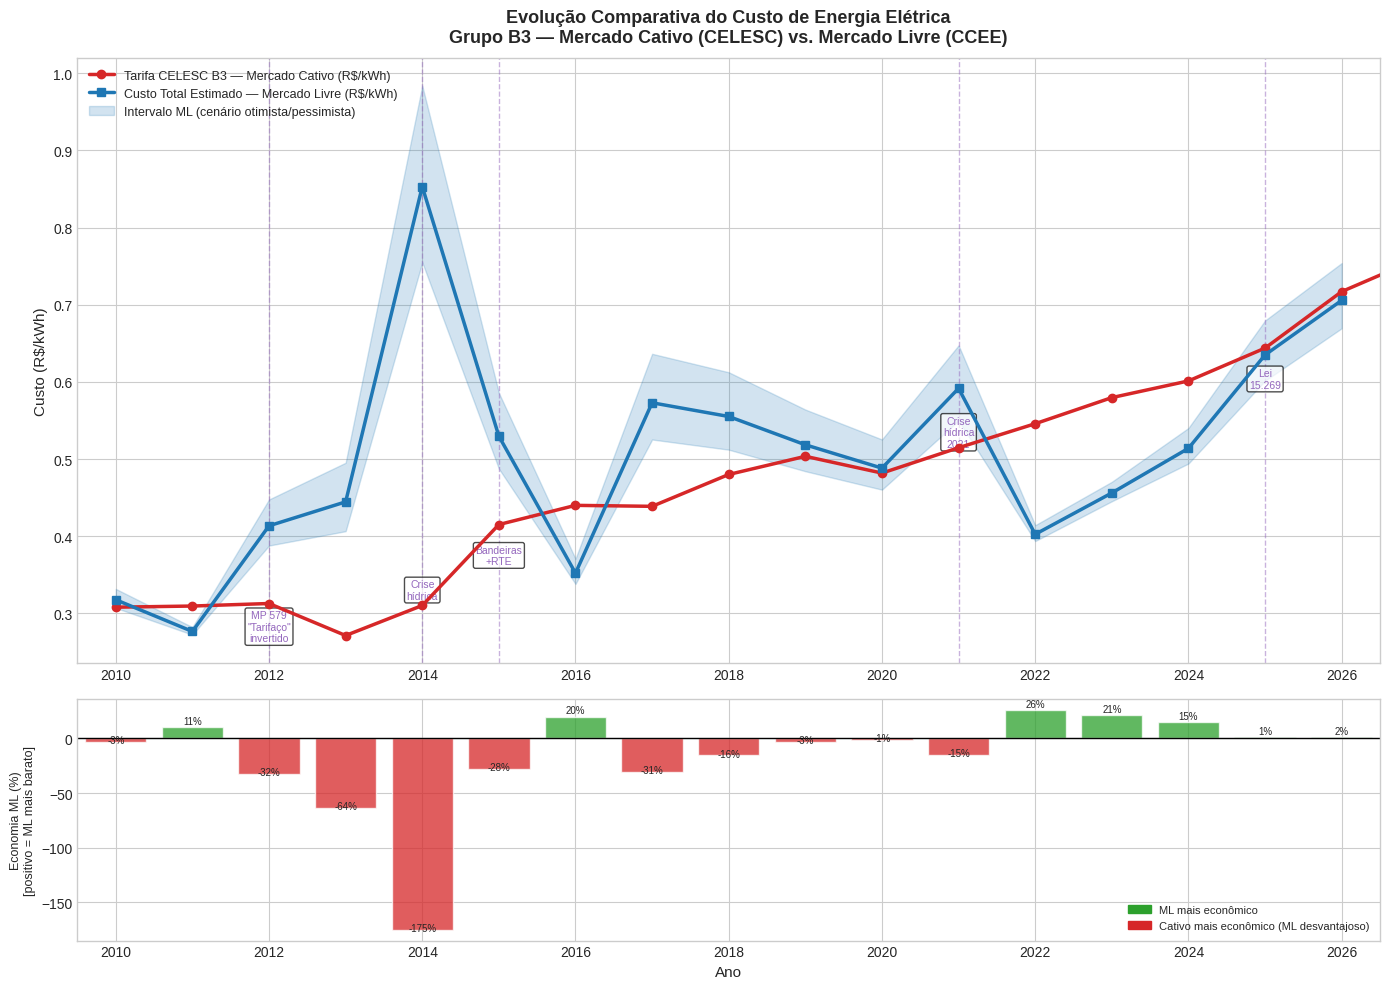

✅ Gráfico salvo: results/plots/fig01_custo_cativo_vs_livre_2010_2026.png


In [6]:
df_comp = pd.merge(tarifa_anual, df_pld, on="ano", how="outer").sort_values("ano")

fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={"height_ratios": [2.5, 1]})
ax1, ax2 = axes

ax1.plot(df_comp["ano"], df_comp["tarifa_celesc_kwh"],
         color=COLORS["cativo"], linewidth=2.5, marker="o", markersize=6,
         label="Tarifa CELESC B3 — Mercado Cativo (R$/kWh)", zorder=5)
ax1.plot(df_comp["ano"], df_comp["custo_ml_kwh"],
         color=COLORS["livre"], linewidth=2.5, marker="s", markersize=6,
         label="Custo Total Estimado — Mercado Livre (R$/kWh)", zorder=5)
ax1.fill_between(df_comp["ano"], df_comp["custo_ml_kwh_otimista"], df_comp["custo_ml_kwh_pessimista"],
                  alpha=0.2, color=COLORS["livre"], label="Intervalo ML (cenário otimista/pessimista)")

eventos_anotados = [
    (2012, 'MP 579\n"Tarifaço"\ninvertido', -0.03),
    (2014, "Crise\nhídrica", 0.02),
    (2015, "Bandeiras\n+RTE", -0.04),
    (2021, "Crise\nhídrica\n2021", 0.02),
    (2025, "Lei\n15.269", -0.04),
]
for ano_ev, texto, dy in eventos_anotados:
    if ano_ev in df_comp["ano"].values:
        y_cativo = df_comp.loc[df_comp["ano"] == ano_ev, "tarifa_celesc_kwh"].values
        if len(y_cativo) > 0:
            ax1.axvline(x=ano_ev, color=COLORS["evento"], linestyle="--", alpha=0.5, linewidth=1)
            ax1.annotate(texto, xy=(ano_ev, y_cativo[0] + dy), fontsize=7.5, color=COLORS["evento"],
                         ha="center", va="center",
                         bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))

ax1.set_title("Evolução Comparativa do Custo de Energia Elétrica\n"
              "Grupo B3 — Mercado Cativo (CELESC) vs. Mercado Livre (CCEE)",
              fontsize=13, fontweight="bold", pad=12)
ax1.set_ylabel("Custo (R$/kWh)", fontsize=11)
ax1.legend(loc="upper left", fontsize=9, framealpha=0.9)
ax1.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax1.set_xlim(2009.5, 2026.5)

df_comp["saving_pct"] = (df_comp["tarifa_celesc_kwh"] - df_comp["custo_ml_kwh"]) / df_comp["tarifa_celesc_kwh"] * 100
cores_saving = [COLORS["saving"] if s >= 0 else COLORS["cativo"] for s in df_comp["saving_pct"]]
bars = ax2.bar(df_comp["ano"], df_comp["saving_pct"], color=cores_saving, alpha=0.75, edgecolor="white")
ax2.axhline(y=0, color="black", linewidth=1)
ax2.set_ylabel("Economia ML (%)\n[positivo = ML mais barato]", fontsize=9)
ax2.set_xlabel("Ano", fontsize=11)
ax2.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax2.set_xlim(2009.5, 2026.5)

for bar, val in zip(bars, df_comp["saving_pct"]):
    if not np.isnan(val):
        ax2.text(bar.get_x() + bar.get_width() / 2, val + (1 if val >= 0 else -3),
                  f"{val:.0f}%", ha="center", va="bottom", fontsize=7)

patch_pos = mpatches.Patch(color=COLORS["saving"], label="ML mais econômico")
patch_neg = mpatches.Patch(color=COLORS["cativo"], label="Cativo mais econômico (ML desvantajoso)")
ax2.legend(handles=[patch_pos, patch_neg], loc="lower right", fontsize=8)

plt.tight_layout()
fname = PLOTS_DIR / "fig01_custo_cativo_vs_livre_2010_2026.png"
plt.savefig(fname, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Gráfico salvo: {Path(fname).relative_to(BASE_DIR).as_posix()}")

### 4.2 Decomposição STL do PLD Submercado Sul

Tendência de longo prazo e sazonalidade da série mensal do PLD Sul (`pld_sul_mensal.csv`).

Série mensal real do PLD: 304 observações (2001-06 a 2026-09)


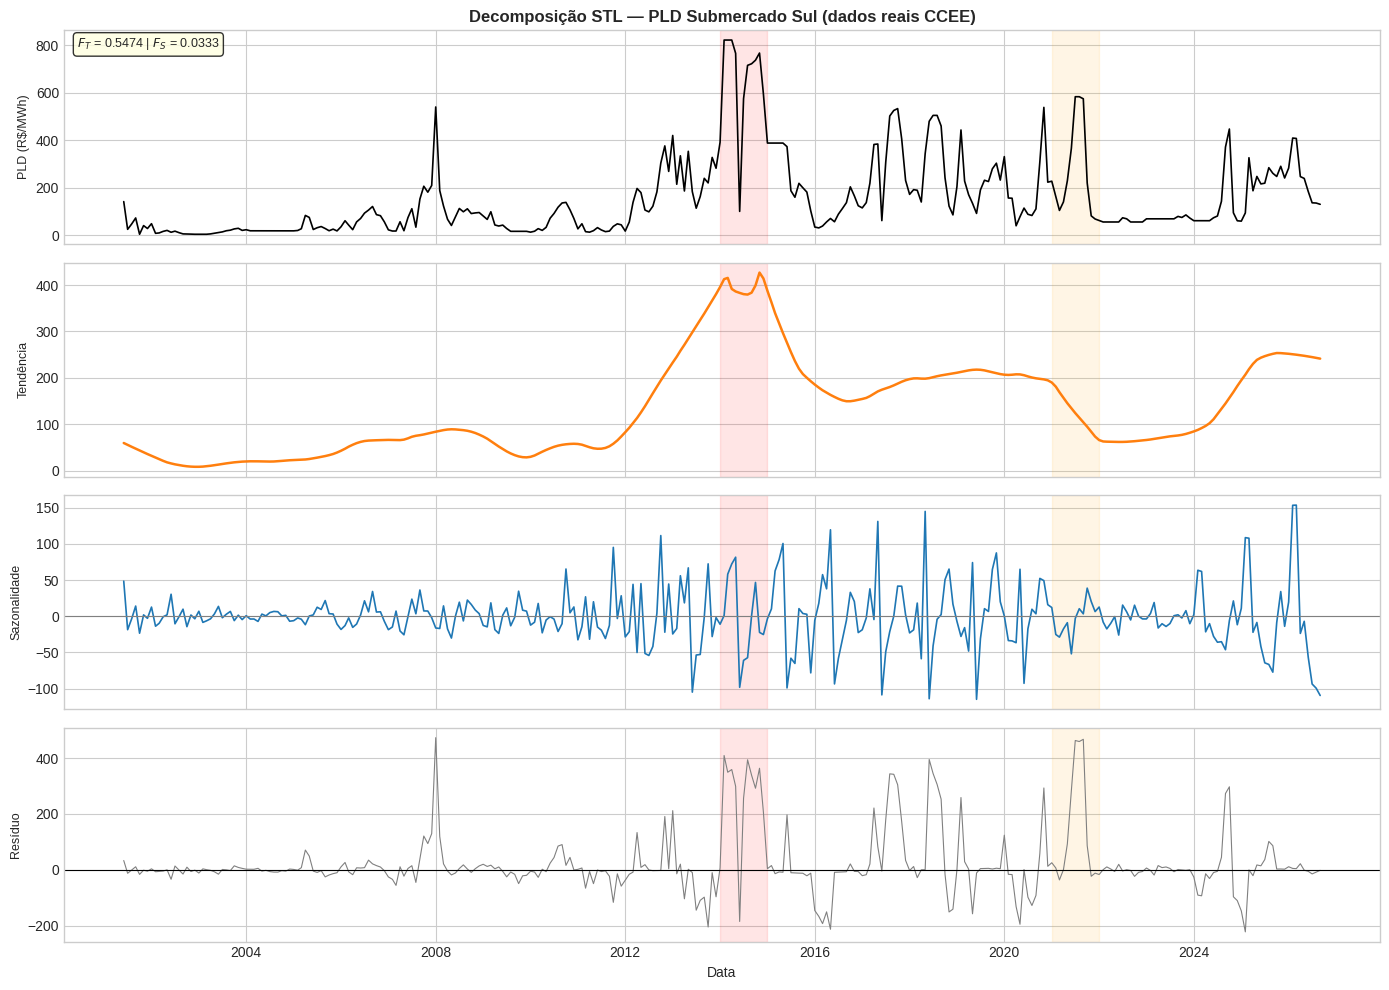


Força de Tendência: 0.5474
Força de Sazonalidade: 0.0333
✅ Gráfico salvo: results/plots/fig02_stl_pld_sul.png


In [7]:
# Série mensal real do PLD (mesma carregada na Seção 2, já indexada por data)
df_pld_mensal = df_pld_mensal_ccee.rename(columns={"pld_sul_rs_mwh": "pld_mensal_mwh"})
print(f"Série mensal real do PLD: {len(df_pld_mensal)} observações "
      f"({df_pld_mensal.index.min():%Y-%m} a {df_pld_mensal.index.max():%Y-%m})")

stl_pld = STL(df_pld_mensal["pld_mensal_mwh"].interpolate(), period=12, robust=True)
result_pld = stl_pld.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df_pld_mensal.index, df_pld_mensal["pld_mensal_mwh"],
             color="black", linewidth=1.2, label="PLD Observado")
axes[0].set_ylabel("PLD (R$/MWh)", fontsize=9)
axes[0].set_title("Decomposição STL — PLD Submercado Sul (dados reais CCEE)", fontsize=12, fontweight="bold")

for ax_i in axes:
    ax_i.axvspan(pd.Timestamp("2014-01-01"), pd.Timestamp("2014-12-31"), alpha=0.1, color="red", label="Crise 2014")
    ax_i.axvspan(pd.Timestamp("2021-01-01"), pd.Timestamp("2021-12-31"), alpha=0.1, color="orange", label="Crise 2021")

axes[1].plot(df_pld_mensal.index, result_pld.trend, color=COLORS["projecao"], linewidth=1.8)
axes[1].set_ylabel("Tendência", fontsize=9)

axes[2].plot(df_pld_mensal.index, result_pld.seasonal, color=COLORS["livre"], linewidth=1.2)
axes[2].set_ylabel("Sazonalidade", fontsize=9)
axes[2].axhline(y=0, color="gray", linewidth=0.8)

axes[3].plot(df_pld_mensal.index, result_pld.resid, color="gray", linewidth=0.8)
axes[3].axhline(y=0, color="black", linewidth=0.8)
axes[3].set_ylabel("Resíduo", fontsize=9)
axes[3].set_xlabel("Data", fontsize=10)

ft_pld = max(0, 1 - np.var(result_pld.resid) / np.var(result_pld.trend + result_pld.resid))
fs_pld = max(0, 1 - np.var(result_pld.resid) / np.var(result_pld.seasonal + result_pld.resid))
axes[0].text(0.01, 0.92, f"$F_T$ = {ft_pld:.4f} | $F_S$ = {fs_pld:.4f}",
             transform=axes[0].transAxes, fontsize=9,
             bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

plt.tight_layout()
fname = PLOTS_DIR / "fig02_stl_pld_sul.png"
plt.savefig(fname, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nForça de Tendência: {ft_pld:.4f}")
print(f"Força de Sazonalidade: {fs_pld:.4f}")
print(f"✅ Gráfico salvo: {Path(fname).relative_to(BASE_DIR).as_posix()}")

---
## 5. Projeção de Consumo, Tarifa e PLD até Dezembro de 2030 (Seção IV.D do relatório)

### 5.1 Consumo Projetado (notebook 03, LSTM)

In [8]:
caminho_previsao = DATA_PROC / "previsao_consumo_b3_lstm_2030.csv"
if not caminho_previsao.exists():
    raise FileNotFoundError(
        "Execute primeiro o Notebook 03 (03_projecao_consumo_b3_2030.ipynb) — "
        "ele gera 'previsao_consumo_b3_lstm_2030.csv', usado aqui como a previsão de consumo B3."
    )

df_consumo_proj = pd.read_csv(caminho_previsao, parse_dates=["data"]).set_index("data")
consumo_previsto_mwh = df_consumo_proj["previsto_mwh"]

print(f"Consumo projetado carregado: {len(consumo_previsto_mwh)} meses "
      f"({consumo_previsto_mwh.index[0]:%Y-%m} a {consumo_previsto_mwh.index[-1]:%Y-%m})")
consumo_previsto_mwh.head()

Consumo projetado carregado: 57 meses (2026-04 a 2030-12)


data
2026-04-01    283448.635245
2026-05-01    278136.500414
2026-06-01    263037.832401
2026-07-01    241767.334201
2026-08-01    221256.146141
Name: previsto_mwh, dtype: float64

### 5.2 Projeção da Tarifa Cativa (TUSD+TE) — 6% a.a. após ago/2027

Mantida nos valores homologados (ANEEL) até ago/2027; após essa data, projetada com crescimento
composto de 6% ao ano (mediana histórica 2011–2027), conforme a Seção IV.D do relatório.

In [9]:
CORTE_TARIFA = pd.Timestamp("2027-08-01")
CRESCIMENTO_TARIFA_AA = 0.06

datas_projecao = consumo_previsto_mwh.index  # abr/2026 a dez/2030 (57 meses)

ultima_tarifa_homologada = df_tarifa_mensal.loc[df_tarifa_mensal.index <= CORTE_TARIFA, "tarifa_cativo_rs_mwh"].iloc[-1]
ultima_tusd_homologada = df_tarifa_mensal.loc[df_tarifa_mensal.index <= CORTE_TARIFA, "tusd_b3_rs_mwh"].iloc[-1]

def projetar_tarifa_cativa(data):
    if data <= CORTE_TARIFA:
        valor = df_tarifa_mensal.loc[:data, "tarifa_cativo_rs_mwh"].iloc[-1]
        return valor
    meses_apos_corte = (data.year - CORTE_TARIFA.year) * 12 + (data.month - CORTE_TARIFA.month)
    return ultima_tarifa_homologada * (1 + CRESCIMENTO_TARIFA_AA) ** (meses_apos_corte / 12)


def projetar_tusd(data):
    if data <= CORTE_TARIFA:
        return df_tarifa_mensal.loc[:data, "tusd_b3_rs_mwh"].iloc[-1]
    meses_apos_corte = (data.year - CORTE_TARIFA.year) * 12 + (data.month - CORTE_TARIFA.month)
    return ultima_tusd_homologada * (1 + CRESCIMENTO_TARIFA_AA) ** (meses_apos_corte / 12)


tarifa_cativa_proj_mwh = pd.Series([projetar_tarifa_cativa(d) for d in datas_projecao], index=datas_projecao)
tusd_proj_mwh = pd.Series([projetar_tusd(d) for d in datas_projecao], index=datas_projecao)

print(f"Tarifa Cativa projetada: {tarifa_cativa_proj_mwh.iloc[0]:,.2f} R$/MWh (abr/2026) "
      f"-> {tarifa_cativa_proj_mwh.iloc[-1]:,.2f} R$/MWh (dez/2030)")

Tarifa Cativa projetada: 695.68 R$/MWh (abr/2026) -> 922.62 R$/MWh (dez/2030)


### 5.3 Projeção do PLD Sul (proxy Livre) — Média Sazonal 2021–2026

Mantido nos valores observados até set/2026; após essa data, projetado pela média sazonal mensal
do calendário (período 2021–2026), dado o caráter volátil e não previsível do PLD no longo prazo.

In [10]:
CORTE_PLD = pd.Timestamp("2026-09-01")

media_sazonal_mensal = (
    df_pld_mensal.loc[(df_pld_mensal.index >= "2021-01-01") & (df_pld_mensal.index <= "2026-06-01"), "pld_mensal_mwh"]
    .groupby(lambda d: d.month)
    .mean()
)


def projetar_pld(data):
    if data <= CORTE_PLD and data in df_pld_mensal.index:
        return df_pld_mensal.loc[data, "pld_mensal_mwh"]
    return media_sazonal_mensal[data.month]


pld_proj_mwh = pd.Series([projetar_pld(d) for d in datas_projecao], index=datas_projecao)

print("Média sazonal mensal do PLD Sul (2021–2026, R$/MWh):")
print(media_sazonal_mensal.round(1).to_string())
print(f"\nPLD projetado: {pld_proj_mwh.iloc[0]:,.2f} R$/MWh (abr/2026) -> "
      f"média {pld_proj_mwh.mean():,.2f} R$/MWh (abr/2026–dez/2030)")

Média sazonal mensal do PLD Sul (2021–2026, R$/MWh):
data
1     127.0
2     142.0
3     170.8
4     126.8
5     150.4
6     160.9
7     205.3
8     230.0
9     268.5
10    209.2
11    121.6
12     99.7

PLD projetado: 247.07 R$/MWh (abr/2026) -> média 167.58 R$/MWh (abr/2026–dez/2030)


---
## 6. Simulação Financeira: Cativo x Livre (Seção IV.E e Tabela IV do relatório)

- Custo mensal Cativo = consumo previsto (MWh) × (TUSD_B3 + TE_B3)
- Custo mensal Livre = consumo previsto (MWh) × (TUSD_B3 + PLD_Sul)

Em ambos os cenários, o consumidor paga a mesma TUSD — a diferença está inteiramente no
componente de energia (TE regulado vs. PLD de mercado).

In [11]:
custo_cativo_total = consumo_previsto_mwh * tarifa_cativa_proj_mwh          # R$ (TUSD+TE)
custo_livre_total = consumo_previsto_mwh * (tusd_proj_mwh + pld_proj_mwh)    # R$ (TUSD+PLD)

df_simulacao = pd.DataFrame({
    "consumo_mwh": consumo_previsto_mwh,
    "tarifa_cativo_rs_mwh": tarifa_cativa_proj_mwh,
    "tusd_rs_mwh": tusd_proj_mwh,
    "pld_rs_mwh": pld_proj_mwh,
    "custo_cativo_rs": custo_cativo_total,
    "custo_livre_rs": custo_livre_total,
})
df_simulacao["economia_pct"] = (
    (df_simulacao["custo_cativo_rs"] - df_simulacao["custo_livre_rs"]) / df_simulacao["custo_cativo_rs"] * 100
)
df_simulacao.to_csv(DATA_PROC / "simulacao_financeira_cativo_livre_2030.csv")

custo_total_cativo_bi = df_simulacao["custo_cativo_rs"].sum() / 1e9
custo_total_livre_bi = df_simulacao["custo_livre_rs"].sum() / 1e9
economia_bi = custo_total_cativo_bi - custo_total_livre_bi
economia_media_pct = df_simulacao["economia_pct"].mean()
economia_min_pct = df_simulacao["economia_pct"].min()
economia_max_pct = df_simulacao["economia_pct"].max()
meses_livre_mais_barato = int((df_simulacao["economia_pct"] > 0).sum())
total_meses = len(df_simulacao)

print("TABELA IV — Indicadores da Simulação Financeira Cativo x Livre "
      f"({datas_projecao[0]:%b/%Y}–{datas_projecao[-1]:%b/%Y})")
print(f"Custo total projetado — Cativo:              R$ {custo_total_cativo_bi:,.2f} bilhões")
print(f"Custo total projetado — Livre/PLD:            R$ {custo_total_livre_bi:,.2f} bilhões")
print(f"Economia projetada (Livre - Cativo):          R$ {economia_bi:,.2f} bilhões")
print(f"Economia média mensal:                        {economia_media_pct:,.1f}%")
print(f"Faixa de economia mensal (mín.–máx.):          {economia_min_pct:,.1f}% a {economia_max_pct:,.1f}%")
print(f"Meses em que Livre é mais barato que Cativo:  {meses_livre_mais_barato} de {total_meses} "
      f"({meses_livre_mais_barato / total_meses * 100:.0f}%)")

TABELA IV — Indicadores da Simulação Financeira Cativo x Livre (Apr/2026–Dec/2030)
Custo total projetado — Cativo:              R$ 11.62 bilhões
Custo total projetado — Livre/PLD:            R$ 8.72 bilhões
Economia projetada (Livre - Cativo):          R$ 2.89 bilhões
Economia média mensal:                        24.8%
Faixa de economia mensal (mín.–máx.):          10.3% a 34.7%
Meses em que Livre é mais barato que Cativo:  57 de 57 (100%)


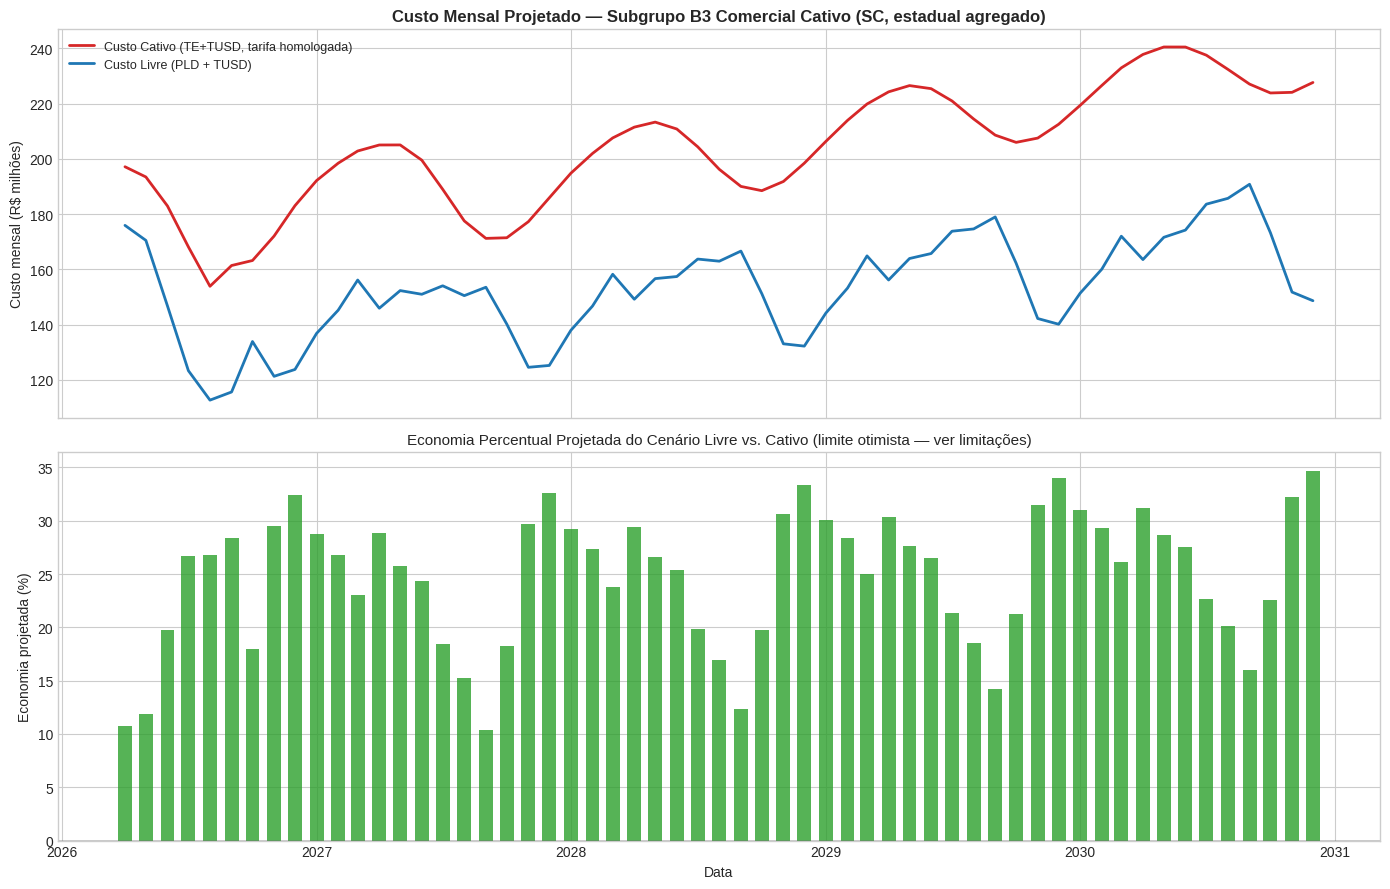

✅ Gráfico salvo: results/plots/fig08_custo_mensal_projetado_economia.png


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axes[0].plot(df_simulacao.index, df_simulacao["custo_cativo_rs"] / 1e6,
             label="Custo Cativo (TE+TUSD, tarifa homologada)", color=COLORS["cativo"], linewidth=2)
axes[0].plot(df_simulacao.index, df_simulacao["custo_livre_rs"] / 1e6,
             label="Custo Livre (PLD + TUSD)", color=COLORS["livre"], linewidth=2)
axes[0].set_title("Custo Mensal Projetado — Subgrupo B3 Comercial Cativo (SC, estadual agregado)",
                   fontsize=12, fontweight="bold")
axes[0].set_ylabel("Custo mensal (R$ milhões)")
axes[0].legend(loc="upper left", fontsize=9)

cores_econ = [COLORS["saving"] if v >= 0 else COLORS["cativo"] for v in df_simulacao["economia_pct"]]
axes[1].bar(df_simulacao.index, df_simulacao["economia_pct"], width=20, color=cores_econ, alpha=0.8)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Economia Percentual Projetada do Cenário Livre vs. Cativo (limite otimista — ver limitações)",
                   fontsize=11)
axes[1].set_ylabel("Economia projetada (%)")
axes[1].set_xlabel("Data")

plt.tight_layout()
fname = PLOTS_DIR / "fig08_custo_mensal_projetado_economia.png"
plt.savefig(fname, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Gráfico salvo: {Path(fname).relative_to(BASE_DIR).as_posix()}")

### 6.1 Simulação com Encargos do Mercado Livre (Seção IV.F, Tabelas V e VI e Fig. 10 do relatório)

A simulação da Seção 6 compara apenas TUSD + TE (Cativo) com TUSD + PLD (Livre). Na prática, o consumidor
que migra paga, além da TUSD e do preço da energia, componentes que no cativo estão embutidos na TE:

| Componente | O que é | Base (R$/MWh) |
|---|---|---|
| Perdas na rede básica | Parcela das perdas de transmissão alocada ao consumo na CCEE | 2% × preço da energia |
| ESS + EER + ERCAP | Serviços do sistema, energia de reserva e reserva de capacidade (via CCEE) | 20 |
| Angra 1 e 2 | Rateio das cotas nucleares, estendido ao ACL a partir de 2026 (Lei 15.235/2025) | 5 |
| Varejista + CCEE | Gestão e representação pelo comercializador varejista, incluindo a contribuição associativa | 20 |
| Prêmio de risco | Preço de contrato acima do PLD | 30 |
| Novos encargos (Lei 15.269/2025) | Sobrecontratação das distribuidoras e Supridor de Última Instância — ainda não regulamentados | 0 (15 no pessimista) |

**CDE, PROINFA, TFSEE, P&D/EE e ONS** já integram a TUSD e são pagos igualmente nos dois ambientes (baixa tensão
mantém a contribuição integral à CDE), por isso **não** entram como custo adicional do Livre. Tributos (ICMS, PIS/COFINS)
ficam fora dos dois lados, como nas tarifas ANEEL. Os valores são premissas de referência e são testados em três cenários.

Premissas de encargos do mercado livre (R$/MWh; perdas em fração do consumo):
                        Otimista   Base  Pessimista
perdas_rede_basica_pct     0.015   0.02        0.03
ess_eer_ercap             10.000  20.00       40.00
angra_1_2                  3.000   5.00        8.00
varejista_ccee            10.000  20.00       40.00
premio_risco_contrato     15.000  30.00       60.00
novos_encargos_lei         0.000   0.00       15.00

Sem encargos (TUSD + PLD): economia média 24.8% | nov/27–dez/30: 26.0%

Simulação com encargos (abr/2026–dez/2030):
            Adicional médio (R$/MWh)  Economia média (%)  Economia média nov/27–dez/30 (%) Faixa mensal (%) Meses Livre mais barato  Economia (R$ bi)
Cenário                                                                                                                                              
Otimista                        40.5                19.7                              21.2       4.8 a 30.4                57 de 57          

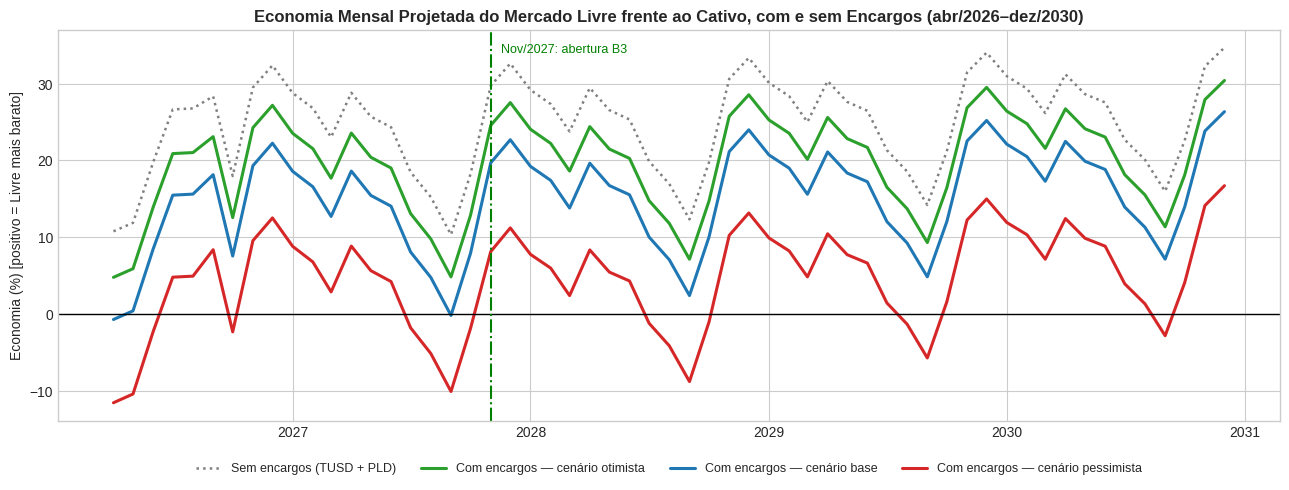

✅ Gráfico salvo: results/plots/fig09_economia_com_encargos_cenarios.png


In [13]:
# ---------------------------------------------------------------------------
# 6.1 Simulação com encargos do mercado livre (itemizados, 3 cenários)
# ---------------------------------------------------------------------------
# O que o consumidor B3 paga nos dois ambientes (valores sem tributos, como as tarifas ANEEL):
#   Cativo = TUSD + TE
#   Livre  = TUSD + preço da energia contratada + encargos pagos via CCEE/varejista
# CDE, PROINFA, TFSEE, P&D/EE e ONS já estão dentro da TUSD e são pagos igualmente nos dois
# ambientes -> NÃO entram como custo adicional do Livre (evita dupla contagem).
# Componentes adicionais do Livre (R$/MWh, referência 2026). São premissas de referência,
# não valores medidos; por isso são avaliados em três cenários.
ENCARGOS_CENARIOS = {
    #                         otimista  base  pessimista
    "perdas_rede_basica_pct": (0.015,   0.020, 0.030),  # fração do consumo sobre o preço da energia
    "ess_eer_ercap":          (10.0,    20.0,  40.0),   # serviços do sistema, reserva de energia e de capacidade
    "angra_1_2":              (3.0,     5.0,   8.0),    # cotas de Angra 1 e 2 (Lei 15.235/2025, a partir de 2026)
    "varejista_ccee":         (10.0,    20.0,  40.0),   # gestão do comercializador varejista + contribuição CCEE
    "premio_risco_contrato":  (15.0,    30.0,  60.0),   # preço de contrato acima do PLD
    "novos_encargos_lei":     (0.0,     0.0,   15.0),   # sobrecontratação e SUI (Lei 15.269/2025), a partir de nov/2027
}
NOMES_CENARIOS = ["Otimista", "Base", "Pessimista"]
INICIO_MIGRACAO_B3 = pd.Timestamp("2027-11-01")

tabela_encargos = pd.DataFrame(ENCARGOS_CENARIOS, index=NOMES_CENARIOS).T
print("Premissas de encargos do mercado livre (R$/MWh; perdas em fração do consumo):")
print(tabela_encargos.to_string())


def custo_livre_com_encargos(idx_cenario, datas, tusd, pld):
    e = {k: v[idx_cenario] for k, v in ENCARGOS_CENARIOS.items()}
    novos = pd.Series([e["novos_encargos_lei"] if d >= INICIO_MIGRACAO_B3 else 0.0 for d in datas], index=datas)
    energia = pld * (1 + e["perdas_rede_basica_pct"]) + e["premio_risco_contrato"]
    encargos = e["ess_eer_ercap"] + e["angra_1_2"] + e["varejista_ccee"] + novos
    return tusd + energia + encargos, energia - pld, encargos


resultados_enc = []
series_enc = {}
for i, nome in enumerate(NOMES_CENARIOS):
    custo_livre_mwh, adic_energia, adic_encargos = custo_livre_com_encargos(i, datas_projecao, tusd_proj_mwh, pld_proj_mwh)
    econ_pct = (tarifa_cativa_proj_mwh - custo_livre_mwh) / tarifa_cativa_proj_mwh * 100
    series_enc[nome] = econ_pct
    apos = econ_pct[econ_pct.index >= INICIO_MIGRACAO_B3]
    resultados_enc.append({
        "Cenário": nome,
        "Adicional médio (R$/MWh)": (adic_energia + adic_encargos).mean(),
        "Economia média (%)": econ_pct.mean(),
        "Economia média nov/27–dez/30 (%)": apos.mean(),
        "Faixa mensal (%)": f"{econ_pct.min():.1f} a {econ_pct.max():.1f}",
        "Meses Livre mais barato": f"{int((econ_pct > 0).sum())} de {len(econ_pct)}",
        "Economia (R$ bi)": (consumo_previsto_mwh * (tarifa_cativa_proj_mwh - custo_livre_mwh)).sum() / 1e9,
    })

df_resultados_enc = pd.DataFrame(resultados_enc).set_index("Cenário")
sem_encargos = df_simulacao["economia_pct"]
print(f"\nSem encargos (TUSD + PLD): economia média {sem_encargos.mean():.1f}% "
      f"| nov/27–dez/30: {sem_encargos[sem_encargos.index >= INICIO_MIGRACAO_B3].mean():.1f}%")
print("\nSimulação com encargos (abr/2026–dez/2030):")
print(df_resultados_enc.round(1).to_string())
df_resultados_enc.to_csv(DATA_PROC / "simulacao_encargos_cenarios_2030.csv")

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(sem_encargos.index, sem_encargos, color="gray", linewidth=1.8, linestyle=":", label="Sem encargos (TUSD + PLD)")
for nome, cor in zip(NOMES_CENARIOS, [COLORS["saving"], COLORS["livre"], COLORS["cativo"]]):
    ax.plot(series_enc[nome].index, series_enc[nome], color=cor, linewidth=2.2, label=f"Com encargos — cenário {nome.lower()}")
ax.axhline(0, color="black", linewidth=1)
ax.axvline(INICIO_MIGRACAO_B3, color="green", linewidth=1.5, linestyle="-.")
ax.text(INICIO_MIGRACAO_B3 + pd.Timedelta(days=15), ax.get_ylim()[1] * 0.92, "Nov/2027: abertura B3", color="green", fontsize=9)
ax.set_title("Economia Mensal Projetada do Mercado Livre frente ao Cativo, com e sem Encargos (abr/2026–dez/2030)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Economia (%) [positivo = Livre mais barato]")
ax.legend(fontsize=9, loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=4, frameon=False)
plt.tight_layout()
fname = PLOTS_DIR / "fig09_economia_com_encargos_cenarios.png"
plt.savefig(fname, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Gráfico salvo: {Path(fname).relative_to(BASE_DIR).as_posix()}")


### 6.2 Validação Histórica com Encargos (2011–2025)

Aplica a mesma comparação ao histórico real de tarifas e PLD, supondo um consumidor B3 exposto ao PLD e os encargos do cenário base (Seção IV.F e Fig. 11 do relatório).

      tarifa_cativo_rs_mwh  pld_mensal_mwh  economia_sem_enc_pct  economia_com_enc_pct
ano                                                                                   
2011                 309.6            28.1                  35.5                  25.6
2012                 312.9           170.6                  -7.6                 -18.4
2013                 271.4           253.4                 -35.5                 -47.1
2014                 310.3           653.6                -150.1                -164.1
2015                 415.2           280.5                  -9.0                 -20.1
2016                 440.0            93.3                  37.5                  27.3
2017                 438.8           317.3                 -13.0                 -24.2
2018                 480.1           286.6                   0.4                 -10.6
2019                 503.6           228.2                  12.3                   1.7
2020                 481.8           185.8 

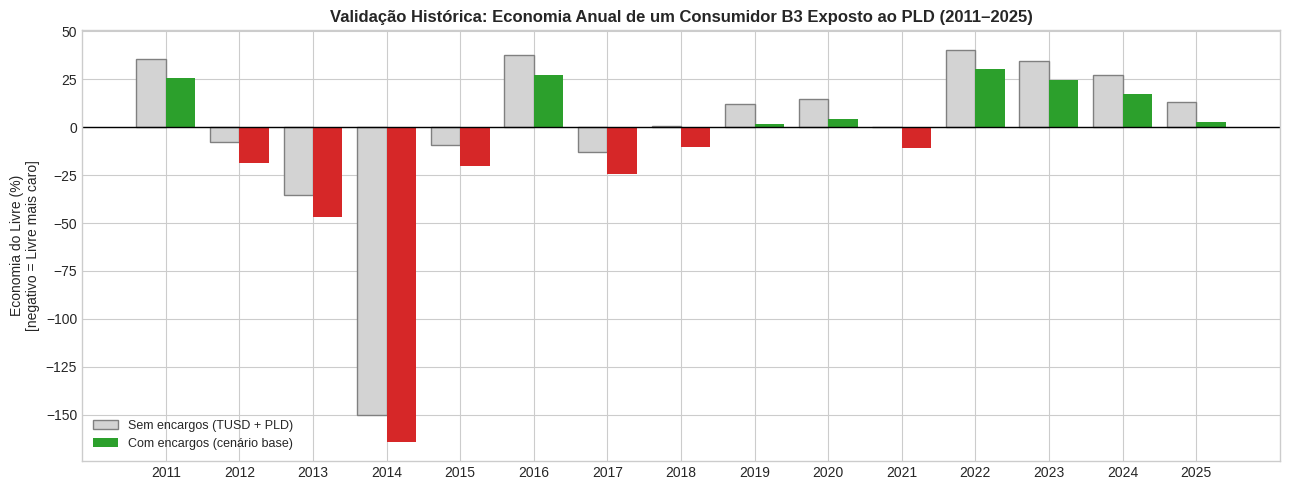

✅ Gráfico salvo: results/plots/fig10_validacao_historica_encargos.png


In [14]:
# ---------------------------------------------------------------------------
# 6.2 Validação histórica 2011–2025 com encargos (cenário base)
# ---------------------------------------------------------------------------
# Pergunta: se um consumidor B3 tivesse migrado, exposto ao PLD, em cada ano do histórico, teria
# pago menos que no cativo? Os componentes fixos do cenário base (R$/MWh de 2026) são trazidos
# para cada mês proporcionalmente ao nível da tarifa cativa daquele mês (indexação tarifária),
# para não aplicar valores de 2026 a preços de 2011. Angra (só a partir de 2026) e os novos
# encargos da Lei 15.269 (a partir de nov/2027) não entram no histórico.
i_base = NOMES_CENARIOS.index("Base")
e_base = {k: v[i_base] for k, v in ENCARGOS_CENARIOS.items()}
tarifa_ref_2026 = df_tarifa_mensal.loc["2026", "tarifa_cativo_rs_mwh"].mean()

hist = df_tarifa_mensal[["tusd_b3_rs_mwh", "te_b3_rs_mwh", "tarifa_cativo_rs_mwh"]].join(
    df_pld_mensal["pld_mensal_mwh"], how="inner").dropna()
hist = hist[(hist.index >= "2011-01-01") & (hist.index <= "2025-12-01")]
indice = hist["tarifa_cativo_rs_mwh"] / tarifa_ref_2026
fixos_base = e_base["ess_eer_ercap"] + e_base["varejista_ccee"] + e_base["premio_risco_contrato"]
hist["custo_livre_sem_enc"] = hist["tusd_b3_rs_mwh"] + hist["pld_mensal_mwh"]
hist["custo_livre_com_enc"] = (hist["tusd_b3_rs_mwh"] + hist["pld_mensal_mwh"] * (1 + e_base["perdas_rede_basica_pct"])
                               + fixos_base * indice)

anual = hist.groupby(hist.index.year).mean()
anual["economia_sem_enc_pct"] = (1 - anual["custo_livre_sem_enc"] / anual["tarifa_cativo_rs_mwh"]) * 100
anual["economia_com_enc_pct"] = (1 - anual["custo_livre_com_enc"] / anual["tarifa_cativo_rs_mwh"]) * 100
anual.index.name = "ano"
anual[["tarifa_cativo_rs_mwh", "pld_mensal_mwh", "economia_sem_enc_pct", "economia_com_enc_pct"]].round(1).to_csv(
    DATA_PROC / "validacao_historica_encargos_2011_2025.csv")

n_desv_sem = int((anual["economia_sem_enc_pct"] < 0).sum())
n_desv_com = int((anual["economia_com_enc_pct"] < 0).sum())
print(anual[["tarifa_cativo_rs_mwh", "pld_mensal_mwh", "economia_sem_enc_pct", "economia_com_enc_pct"]].round(1).to_string())
print(f"\nAnos desvantajosos para o Livre (2011–2025, {len(anual)} anos): "
      f"sem encargos {n_desv_sem} | com encargos (base) {n_desv_com}")

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(anual))
ax.bar(x - 0.2, anual["economia_sem_enc_pct"], width=0.4, color="lightgray", edgecolor="gray", label="Sem encargos (TUSD + PLD)")
cores = [COLORS["saving"] if v >= 0 else COLORS["cativo"] for v in anual["economia_com_enc_pct"]]
ax.bar(x + 0.2, anual["economia_com_enc_pct"], width=0.4, color=cores, label="Com encargos (cenário base)")
ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(anual.index)
ax.set_ylabel("Economia do Livre (%)\n[negativo = Livre mais caro]")
ax.set_title("Validação Histórica: Economia Anual de um Consumidor B3 Exposto ao PLD (2011–2025)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
fname = PLOTS_DIR / "fig10_validacao_historica_encargos.png"
plt.savefig(fname, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Gráfico salvo: {Path(fname).relative_to(BASE_DIR).as_posix()}")


---
## 7. Aspectos Contratuais da Migração ao Mercado Livre

### 7.1 Prazo de Contratação

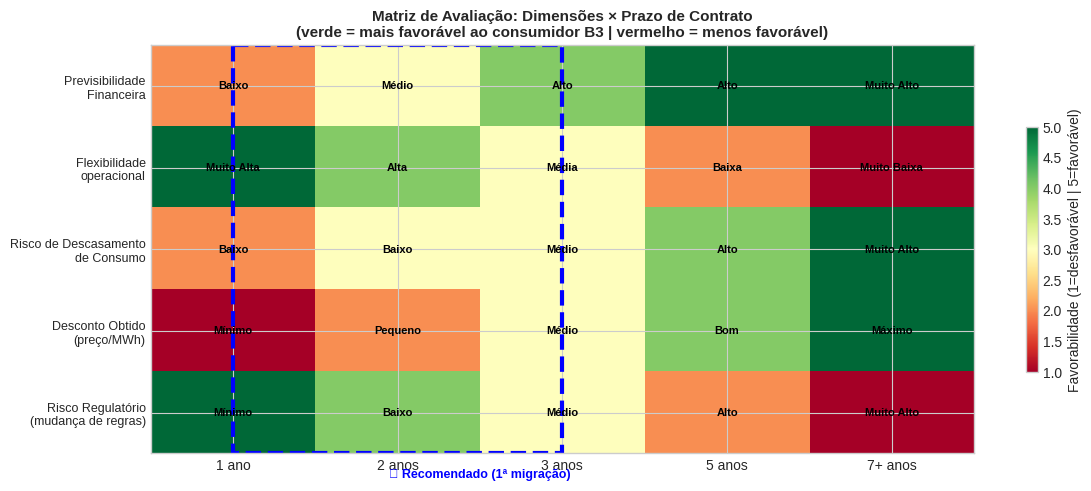

✅ Gráfico salvo: results/plots/fig05_matriz_prazo_contrato.png


In [15]:
fig, ax = plt.subplots(figsize=(12, 5))

prazos_anos = ["1 ano", "2 anos", "3 anos", "5 anos", "7+ anos"]
dimensoes = ["Previsibilidade\nFinanceira", "Flexibilidade\noperacional",
             "Risco de Descasamento\nde Consumo", "Desconto Obtido\n(preço/MWh)",
             "Risco Regulatório\n(mudança de regras)"]

matriz = np.array([
    [2, 3, 4, 5, 5],
    [5, 4, 3, 2, 1],
    [2, 3, 3, 4, 5],
    [1, 2, 3, 4, 5],
    [5, 4, 3, 2, 1],
])

im = ax.imshow(matriz, cmap="RdYlGn", aspect="auto", vmin=1, vmax=5)
ax.set_xticks(range(len(prazos_anos)))
ax.set_xticklabels(prazos_anos, fontsize=10)
ax.set_yticks(range(len(dimensoes)))
ax.set_yticklabels(dimensoes, fontsize=9)
ax.set_title("Matriz de Avaliação: Dimensões × Prazo de Contrato\n"
             "(verde = mais favorável ao consumidor B3 | vermelho = menos favorável)",
             fontsize=11, fontweight="bold")

labels_cell = [
    ["Baixo", "Médio", "Alto", "Alto", "Muito Alto"],
    ["Muito Alta", "Alta", "Média", "Baixa", "Muito Baixa"],
    ["Baixo", "Baixo", "Médio", "Alto", "Muito Alto"],
    ["Mínimo", "Pequeno", "Médio", "Bom", "Máximo"],
    ["Mínimo", "Baixo", "Médio", "Alto", "Muito Alto"],
]
for i in range(len(dimensoes)):
    for j in range(len(prazos_anos)):
        ax.text(j, i, labels_cell[i][j], ha="center", va="center", fontsize=8, color="black", fontweight="bold")

rect = plt.Rectangle((0.5 - 0.5, -0.5), 2, len(dimensoes),
                      fill=False, edgecolor="blue", linewidth=3, linestyle="--")
ax.add_patch(rect)
ax.text(1.5, len(dimensoes) - 0.2, "★ Recomendado (1ª migração)", ha="center", color="blue", fontsize=9, fontweight="bold")

plt.colorbar(im, ax=ax, shrink=0.6, label="Favorabilidade (1=desfavorável | 5=favorável)")
plt.tight_layout()
fname = PLOTS_DIR / "fig05_matriz_prazo_contrato.png"
plt.savefig(fname, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Gráfico salvo: {Path(fname).relative_to(BASE_DIR).as_posix()}")

In [16]:
clausulas = {
    "Take or Pay": {
        "descricao": "Compromisso de pagar volume mínimo de energia, mesmo se o consumo real for menor.",
        "padrao_mercado": "80-90% do volume base contratado",
        "risco": "ALTO se consumo sazonal ou empresa com variação de produção",
        "recomendacao": "Negociar volume base conservador (80% da média dos últimos 12 meses)",
    },
    "Flexibilidade de Consumo (swing)": {
        "descricao": "Margem percentual de variação do consumo sem multa contratual.",
        "padrao_mercado": "±10% do volume base (padrão); negociável até ±20%",
        "risco": "MÉDIO — desvios fora da margem expõem ao PLD spot (preço de curto prazo)",
        "recomendacao": "Exigir mínimo ±15% para consumidores B3 com sazonalidade",
    },
    "Modalidade de Preço": {
        "descricao": "Forma de indexação do preço da energia ao longo do contrato.",
        "padrao_mercado": "Preço fixo, IPCA, PLD médio ou IGP-M",
        "risco": "VARIÁVEL — preço fixo protege mas não captura quedas do PLD; indexado ao PLD maximiza exposição",
        "recomendacao": "Preço fixo ou IPCA para contratos de 2-3 anos (reduz incerteza do PLD)",
    },
    "Rescisão Antecipada": {
        "descricao": "Penalidade por encerramento do contrato antes do prazo acordado.",
        "padrao_mercado": "3 a 6 meses de energia (valor-face do contrato)",
        "risco": "ALTO em caso de encerramento de atividade ou mudança de endereço",
        "recomendacao": "Negociar cláusula de saída por força maior e período de carência de 6 meses",
    },
    "Representação junto à CCEE": {
        "descricao": "O consumidor B3 precisará de um Comercializador Varejista para representá-lo na CCEE.",
        "padrao_mercado": "Comercializador varejista assume responsabilidade de liquidação",
        "risco": "BAIXO (risco operacional do comercializador, não do consumidor)",
        "recomendacao": "Verificar solidez financeira e histórico do comercializador escolhido",
    },
    "Prazo de Notificação de Saída": {
        "descricao": "Aviso prévio obrigatório para não renovação ou rescisão.",
        "padrao_mercado": "180 dias antes do vencimento",
        "risco": "MÉDIO — se não notificado, pode haver renovação automática",
        "recomendacao": "Incluir alerta no calendário de gestão 9 meses antes do vencimento",
    },
}

print("=" * 80)
print("📋 ASPECTOS CONTRATUAIS CRÍTICOS — Migração ao Mercado Livre (Grupo B3)")
print("=" * 80)
for clausula, info in clausulas.items():
    print(f"\n🔹 {clausula}")
    print(f'   Descrição:       {info["descricao"]}')
    print(f'   Padrão mercado:  {info["padrao_mercado"]}')
    print(f'   Risco:           {info["risco"]}')
    print(f'   ✅ Recomendação: {info["recomendacao"]}')

📋 ASPECTOS CONTRATUAIS CRÍTICOS — Migração ao Mercado Livre (Grupo B3)

🔹 Take or Pay
   Descrição:       Compromisso de pagar volume mínimo de energia, mesmo se o consumo real for menor.
   Padrão mercado:  80-90% do volume base contratado
   Risco:           ALTO se consumo sazonal ou empresa com variação de produção
   ✅ Recomendação: Negociar volume base conservador (80% da média dos últimos 12 meses)

🔹 Flexibilidade de Consumo (swing)
   Descrição:       Margem percentual de variação do consumo sem multa contratual.
   Padrão mercado:  ±10% do volume base (padrão); negociável até ±20%
   Risco:           MÉDIO — desvios fora da margem expõem ao PLD spot (preço de curto prazo)
   ✅ Recomendação: Exigir mínimo ±15% para consumidores B3 com sazonalidade

🔹 Modalidade de Preço
   Descrição:       Forma de indexação do preço da energia ao longo do contrato.
   Padrão mercado:  Preço fixo, IPCA, PLD médio ou IGP-M
   Risco:           VARIÁVEL — preço fixo protege mas não captura quedas

---
## 8. Análise de Sensibilidade e Risco Hidrológico (Seção IV.H do relatório)

Mesmo com os encargos da Seção 6.1, a projeção pressupõe um PLD semelhante ao de 2021–2026 e não captura a repetição de uma crise hídrica: em 2014, o PLD Sul teve média anual de R$ 654/MWh; em 2021, atingiu o teto de R$ 584/MWh em julho (média anual de R$ 279/MWh).

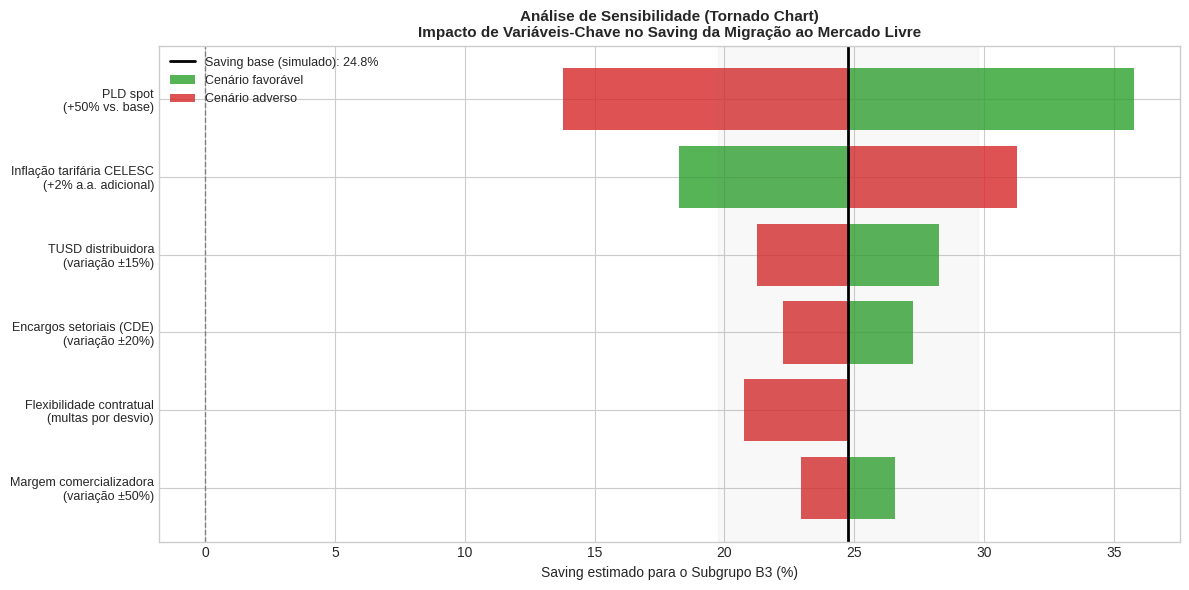

✅ Gráfico salvo: results/plots/fig06_tornado_sensibilidade.png


In [17]:
fig, ax = plt.subplots(figsize=(12, 6))

saving_base_pct = economia_media_pct  # calculado na Seção 6, a partir da simulação real (não mais um valor fixo)

variaveis = [
    ("Inflação tarifária CELESC\n(+2% a.a. adicional)", +6.5, -6.5),
    ("PLD spot\n(+50% vs. base)", -11.0, +11.0),
    ("TUSD distribuidora\n(variação ±15%)", -3.5, +3.5),
    ("Encargos setoriais (CDE)\n(variação ±20%)", -2.5, +2.5),
    ("Margem comercializadora\n(variação ±50%)", -1.8, +1.8),
    ("Flexibilidade contratual\n(multas por desvio)", -4.0, +0.0),
]
variaveis.sort(key=lambda x: abs(x[1] - x[2]))
nomes = [v[0] for v in variaveis]
impacto_neg = [v[1] for v in variaveis]
impacto_pos = [v[2] for v in variaveis]

y_pos = np.arange(len(variaveis))
ax.barh(y_pos, impacto_pos, left=saving_base_pct, color=COLORS["saving"], alpha=0.8, label="Cenário favorável")
ax.barh(y_pos, impacto_neg, left=saving_base_pct, color=COLORS["cativo"], alpha=0.8, label="Cenário adverso")
ax.axvline(x=saving_base_pct, color="black", linewidth=2, label=f"Saving base (simulado): {saving_base_pct:.1f}%")
ax.axvline(x=0, color="gray", linewidth=1, linestyle="--")

ax.set_yticks(y_pos)
ax.set_yticklabels(nomes, fontsize=9)
ax.set_xlabel("Saving estimado para o Subgrupo B3 (%)", fontsize=10)
ax.set_title("Análise de Sensibilidade (Tornado Chart)\n"
             "Impacto de Variáveis-Chave no Saving da Migração ao Mercado Livre",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
ax.axvspan(saving_base_pct - 5, saving_base_pct + 5, alpha=0.05, color="gray")

plt.tight_layout()
fname = PLOTS_DIR / "fig06_tornado_sensibilidade.png"
plt.savefig(fname, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Gráfico salvo: {Path(fname).relative_to(BASE_DIR).as_posix()}")

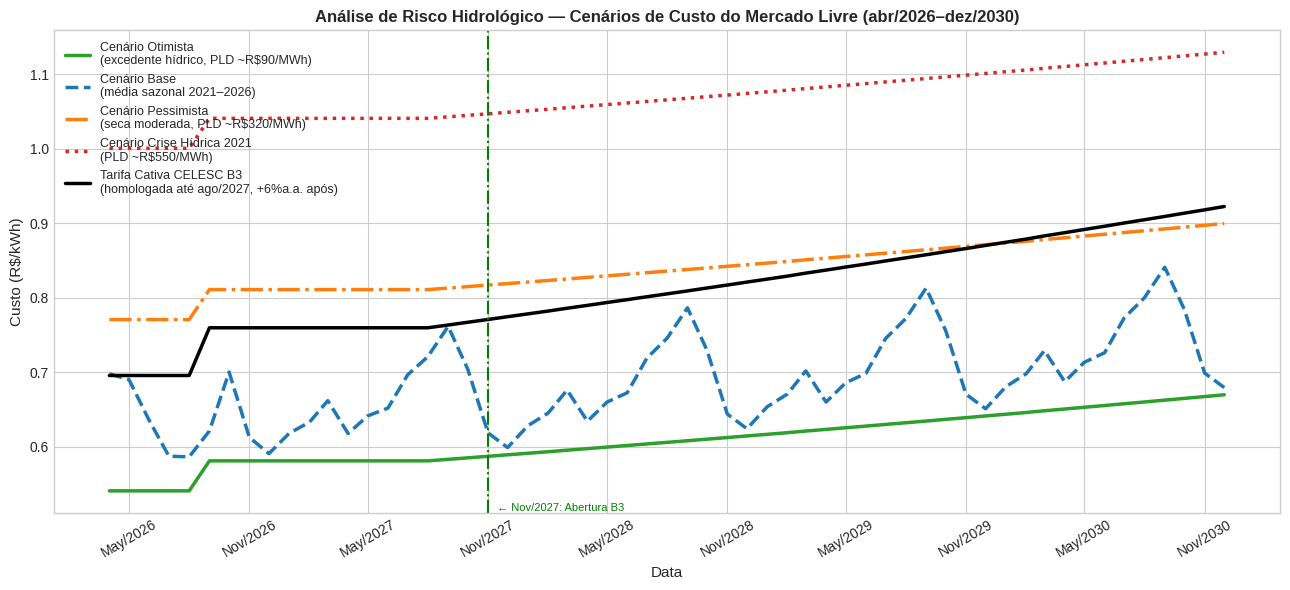

✅ Gráfico salvo: results/plots/fig07_cenarios_risco_hidrologico.png


In [18]:
fig, ax = plt.subplots(figsize=(13, 6))

cenarios = {
    "Cenário Otimista\n(excedente hídrico, PLD ~R$90/MWh)": [0.090 + tusd_proj_mwh.loc[d] / 1000 + ENCARGOS_MARGEM_KWH for d in datas_projecao],
    "Cenário Base\n(média sazonal 2021–2026)": (pld_proj_mwh / 1000 + tusd_proj_mwh / 1000 + ENCARGOS_MARGEM_KWH).values,
    "Cenário Pessimista\n(seca moderada, PLD ~R$320/MWh)": [0.320 + tusd_proj_mwh.loc[d] / 1000 + ENCARGOS_MARGEM_KWH for d in datas_projecao],
    "Cenário Crise Hídrica 2021\n(PLD ~R$550/MWh)": [0.550 + tusd_proj_mwh.loc[d] / 1000 + ENCARGOS_MARGEM_KWH for d in datas_projecao],
}

cores_cenarios = [COLORS["saving"], COLORS["livre"], COLORS["projecao"], COLORS["cativo"]]
estilos = ["-", "--", "-.", ":"]

for (nome_cen, valores), cor, ls in zip(cenarios.items(), cores_cenarios, estilos):
    ax.plot(datas_projecao, valores, color=cor, linewidth=2.5, linestyle=ls, label=nome_cen)

ax.plot(datas_projecao, tarifa_cativa_proj_mwh / 1000, color="black", linewidth=2.5,
        label="Tarifa Cativa CELESC B3\n(homologada até ago/2027, +6%a.a. após)")

ax.axvline(x=pd.Timestamp("2027-11-01"), color="green", linewidth=1.5, linestyle="-.")
ax.text(pd.Timestamp("2027-11-15"), ax.get_ylim()[0], "← Nov/2027: Abertura B3",
        fontsize=8, color="green", va="bottom")

ax.set_title("Análise de Risco Hidrológico — Cenários de Custo do Mercado Livre (abr/2026–dez/2030)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Custo (R$/kWh)", fontsize=11)
ax.set_xlabel("Data", fontsize=11)
ax.legend(loc="upper left", fontsize=9, framealpha=0.9)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b/%Y"))
plt.xticks(rotation=30)

plt.tight_layout()
fname = PLOTS_DIR / "fig07_cenarios_risco_hidrologico.png"
plt.savefig(fname, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Gráfico salvo: {Path(fname).relative_to(BASE_DIR).as_posix()}")

---
## 9. Síntese e Exportação de Dados Processados

In [19]:
df_final = df_simulacao.reset_index().rename(columns={"index": "data"})
df_final.to_csv(DATA_PROC / "comparativo_custo_b3_cativo_vs_livre_2030.csv", index=False, decimal=",")

print("📊 TABELA IV — Indicadores da Simulação Financeira Cativo x Livre")
print("=" * 75)
print(f'{"Indicador":<45} | {"Valor":>25}')
print("-" * 75)
print(f'{"Custo total projetado — Cativo":<45} | {f"R$ {custo_total_cativo_bi:,.2f} bilhões":>25}')
print(f'{"Custo total projetado — Livre/PLD":<45} | {f"R$ {custo_total_livre_bi:,.2f} bilhões":>25}')
print(f'{"Economia projetada (Livre - Cativo)":<45} | {f"R$ {economia_bi:,.2f} bilhões":>25}')
print(f'{"Economia média mensal":<45} | {f"{economia_media_pct:,.1f}%":>25}')
print(f'{"Faixa de economia mensal":<45} | {f"{economia_min_pct:,.1f}% a {economia_max_pct:,.1f}%":>25}')
print(f'{"Meses em que Livre é mais barato":<45} | {f"{meses_livre_mais_barato} de {total_meses}":>25}')
print("=" * 75)
print(f"\n✅ CSV exportado: data/processed/comparativo_custo_b3_cativo_vs_livre_2030.csv")
print(
    "\n⚠️  Limitações (Seções IV.F e IV.H do relatório): os valores acima não incluem os encargos "
    "do mercado livre (ver Seção 6.1), e a projeção não incorpora o risco de repetição de uma "
    "crise hídrica."
)

📊 TABELA IV — Indicadores da Simulação Financeira Cativo x Livre
Indicador                                     |                     Valor
---------------------------------------------------------------------------
Custo total projetado — Cativo                |          R$ 11.62 bilhões
Custo total projetado — Livre/PLD             |           R$ 8.72 bilhões
Economia projetada (Livre - Cativo)           |           R$ 2.89 bilhões
Economia média mensal                         |                     24.8%
Faixa de economia mensal                      |             10.3% a 34.7%
Meses em que Livre é mais barato              |                  57 de 57

✅ CSV exportado: data/processed/comparativo_custo_b3_cativo_vs_livre_2030.csv

⚠️  Limitações (Seções IV.F e IV.H do relatório): os valores acima não incluem os encargos do mercado livre (ver Seção 6.1), e a projeção não incorpora o risco de repetição de uma crise hídrica.
